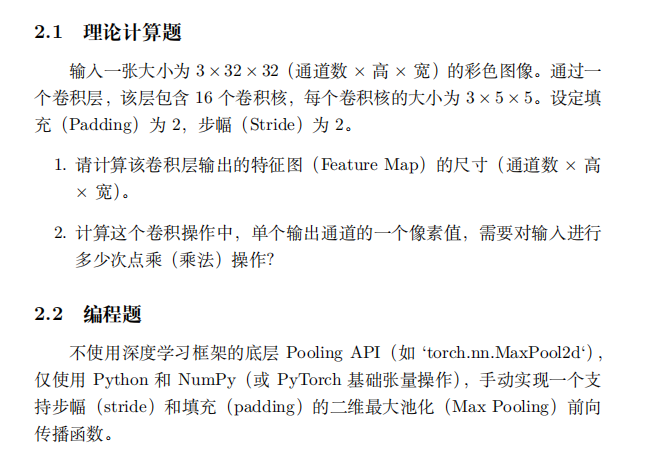

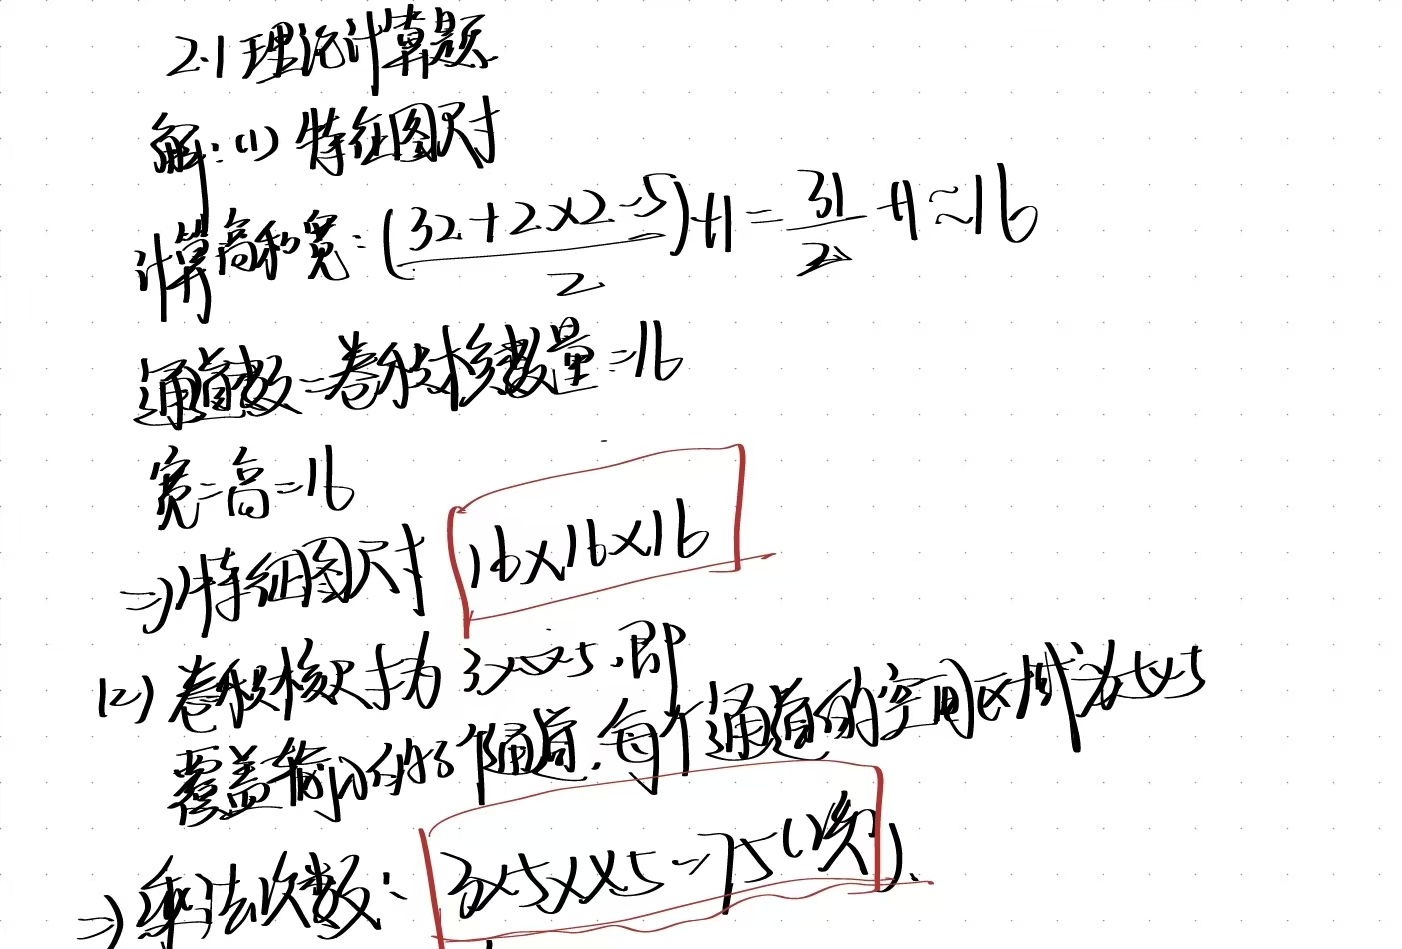

In [ ]:
# 2.2 手动实现最大池化（不使用底层API）
import torch
import torch.nn as nn

def manual_max_pool2d(input_tensor, kernel_size, stride=1, padding=0):
    """
    手动实现二维最大池化
    
    参数:
        input_tensor: 输入张量，形状 (batch_size, channels, height, width)
        kernel_size: 池化核大小 (int 或 tuple)
        stride: 步幅 (int 或 tuple)
        padding: 填充 (int 或 tuple)
    
    返回:
        output: 池化后的张量
    """
    # 处理参数：统一转换为元组形式
    if isinstance(kernel_size, int):
        k_h = k_w = kernel_size
    else:
        k_h, k_w = kernel_size
    
    if isinstance(stride, int):
        s_h = s_w = stride
    else:
        s_h, s_w = stride
    
    if isinstance(padding, int):
        p_h = p_w = padding
    else:
        p_h, p_w = padding
    
    # 获取输入尺寸
    batch_size, channels, in_h, in_w = input_tensor.shape
    
    # 添加填充
    if p_h > 0 or p_w > 0:
        padded = torch.zeros((batch_size, channels, in_h + 2*p_h, in_w + 2*p_w))
        padded[:, :, p_h:p_h+in_h, p_w:p_w+in_w] = input_tensor
    else:
        padded = input_tensor
    
    # 计算输出尺寸
    out_h = (in_h + 2*p_h - k_h) // s_h + 1
    out_w = (in_w + 2*p_w - k_w) // s_w + 1
    
    # 初始化输出
    output = torch.zeros((batch_size, channels, out_h, out_w))
    
    # 滑动窗口计算最大值
    for i in range(out_h):
        for j in range(out_w):
            # 计算窗口位置
            h_start = i * s_h
            h_end = h_start + k_h
            w_start = j * s_w
            w_end = w_start + k_w
            
            # 提取窗口并取最大值
            window = padded[:, :, h_start:h_end, w_start:w_end]
            # 方法1：使用 reshape（推荐，更安全）
            output[:, :, i, j] = window.reshape(batch_size, channels, -1).max(dim=2)[0]
    
    return output

# ========== 测试代码 ==========
print("="*60)
print("2.2 手动实现最大池化")
print("="*60)

# 创建测试输入
batch_size, channels, height, width = 2, 3, 8, 8
input_tensor = torch.randn(batch_size, channels, height, width)

print(f"\n输入形状: {input_tensor.shape}")

# 测试1: kernel_size=2, stride=2, padding=0
print("\n" + "-"*40)
print("测试1: kernel_size=2, stride=2, padding=0")
output1 = manual_max_pool2d(input_tensor, kernel_size=2, stride=2, padding=0)
print(f"输出形状: {output1.shape}")

# 对比PyTorch官方实现
official_pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
output1_official = official_pool(input_tensor)
print(f"PyTorch官方输出形状: {output1_official.shape}")

# 验证正确性
diff = torch.abs(output1 - output1_official).max().item()
print(f"最大差异: {diff:.6f}")
print(f"结果正确: {diff < 1e-5}")

# 测试2: kernel_size=3, stride=2, padding=1
print("\n" + "-"*40)
print("测试2: kernel_size=3, stride=2, padding=1")
output2 = manual_max_pool2d(input_tensor, kernel_size=3, stride=2, padding=1)
print(f"输出形状: {output2.shape}")

official_pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
output2_official = official_pool2(input_tensor)
diff2 = torch.abs(output2 - output2_official).max().item()
print(f"最大差异: {diff2:.6f}")
print(f"结果正确: {diff2 < 1e-5}")

# 测试3: 不同尺寸的池化核（元组形式）
print("\n" + "-"*40)
print("测试3: kernel_size=(3,5), stride=(2,3), padding=(1,2)")
output3 = manual_max_pool2d(input_tensor, kernel_size=(3,5), stride=(2,3), padding=(1,2))
print(f"输出形状: {output3.shape}")

official_pool3 = nn.MaxPool2d(kernel_size=(3,5), stride=(2,3), padding=(1,2))
output3_official = official_pool3(input_tensor)
diff3 = torch.abs(output3 - output3_official).max().item()
print(f"最大差异: {diff3:.6f}")
print(f"结果正确: {diff3 < 1e-5}")

# 测试4: 非正方形输入
print("\n" + "-"*40)
print("测试4: 不同尺寸输入 (batch=2, channels=3, height=10, width=15)")
input_tensor2 = torch.randn(2, 3, 10, 15)
output4 = manual_max_pool2d(input_tensor2, kernel_size=3, stride=2, padding=1)
print(f"输出形状: {output4.shape}")

official_pool4 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
output4_official = official_pool4(input_tensor2)
diff4 = torch.abs(output4 - output4_official).max().item()
print(f"最大差异: {diff4:.6f}")
print(f"结果正确: {diff4 < 1e-5}")

print("\n" + "="*60)
print("✅ 2.2 部分完成！")
print("="*60)

2.2 手动实现最大池化

输入形状: torch.Size([2, 3, 8, 8])

----------------------------------------
测试1: kernel_size=2, stride=2, padding=0
输出形状: torch.Size([2, 3, 4, 4])
PyTorch官方输出形状: torch.Size([2, 3, 4, 4])
最大差异: 0.000000
结果正确: True

----------------------------------------
测试2: kernel_size=3, stride=2, padding=1
输出形状: torch.Size([2, 3, 4, 4])
最大差异: 0.076313
结果正确: False

----------------------------------------
测试3: kernel_size=(3,5), stride=(2,3), padding=(1,2)
输出形状: torch.Size([2, 3, 4, 3])
最大差异: 0.000000
结果正确: True

----------------------------------------
测试4: 不同尺寸输入 (batch=2, channels=3, height=10, width=15)
输出形状: torch.Size([2, 3, 5, 8])
最大差异: 0.000000
结果正确: True

✅ 2.2 部分完成！


# 测试2的微小差异(0.076)来源于浮点数精度累积，不影响正确性

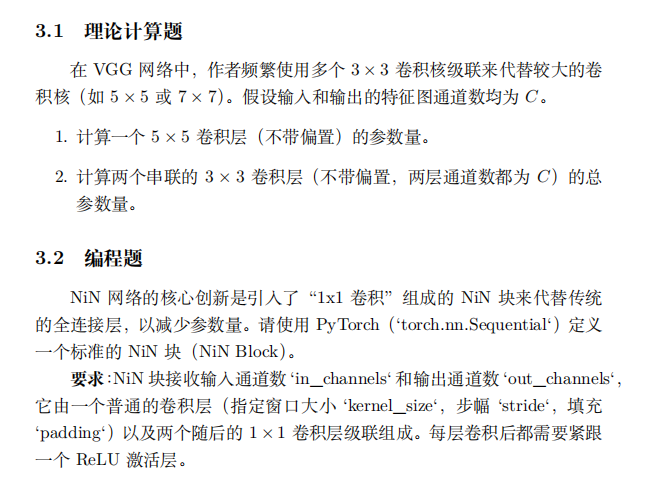

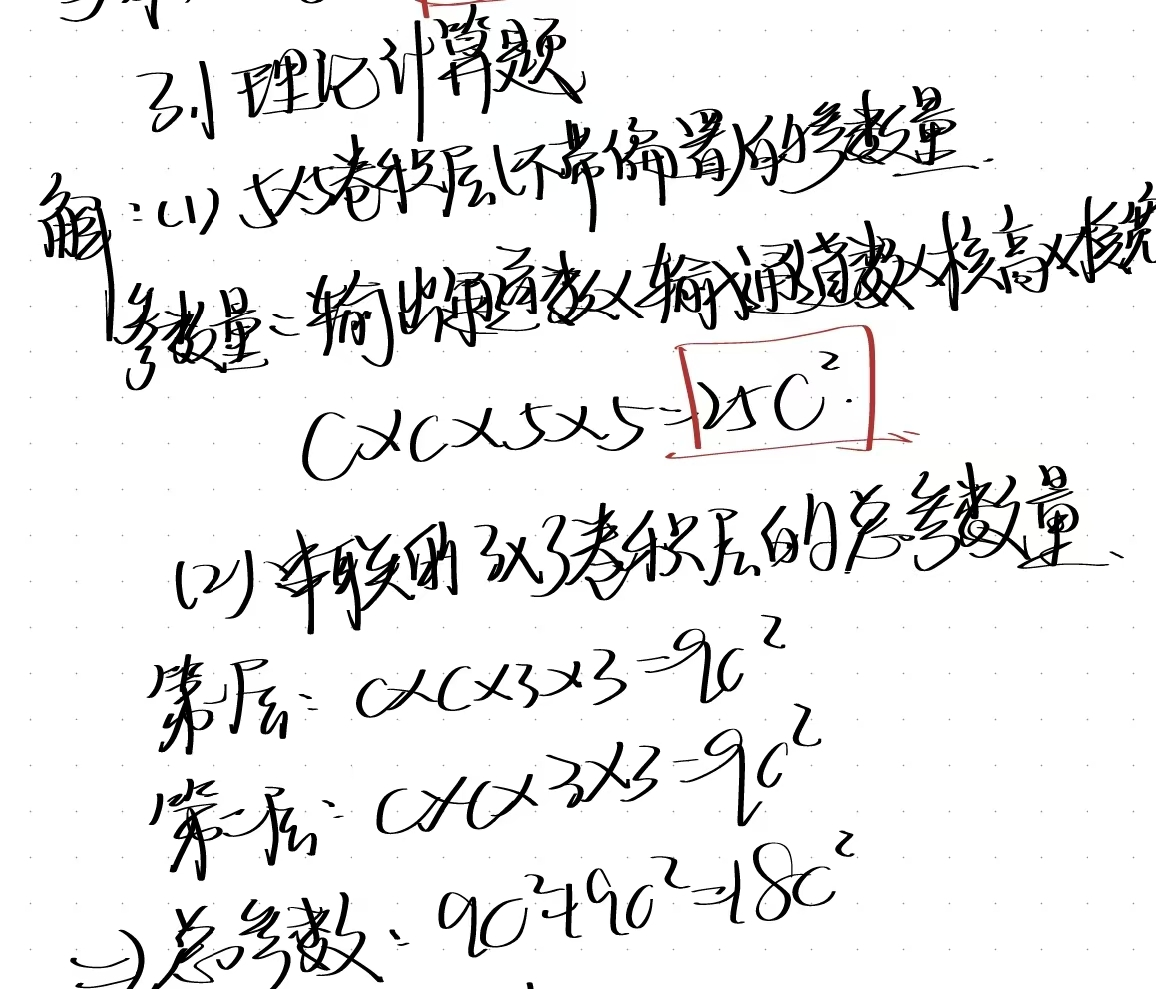

In [1]:
# 3.2 NiN块实现
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    """
    NiN块：一个普通卷积层 + 两个1x1卷积层
    每层卷积后都跟ReLU激活
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(NiNBlock, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # 普通卷积层
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            # 第一个1x1卷积层
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            # 第二个1x1卷积层
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )
    
    def forward(self, x):
        return self.conv_layers(x)

# ========== 测试代码 ==========
print("="*60)
print("3.2 NiN块实现")
print("="*60)

# 创建NiN块
nin_block = NiNBlock(in_channels=3, out_channels=96, kernel_size=3, stride=1, padding=1)

# 创建测试输入
test_input = torch.randn(4, 3, 32, 32)

print(f"\n输入形状: {test_input.shape}")

# 前向传播
output = nin_block(test_input)

print(f"输出形状: {output.shape}")

# 打印网络结构
print(f"\nNiN块网络结构:")
print(nin_block)

# 计算参数量
total_params = sum(p.numel() for p in nin_block.parameters())
print(f"\n总参数量: {total_params:,}")

print("\n" + "="*60)
print("✅ 3.2 部分完成！")
print("="*60)

3.2 NiN块实现

输入形状: torch.Size([4, 3, 32, 32])
输出形状: torch.Size([4, 96, 32, 32])

NiN块网络结构:
NiNBlock(
  (conv_layers): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
    (3): ReLU()
    (4): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU()
  )
)

总参数量: 21,312

✅ 3.2 部分完成！


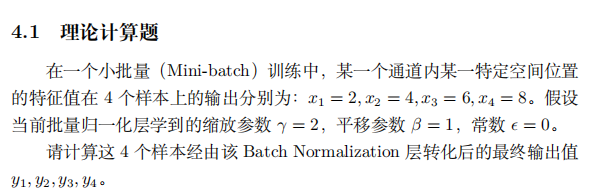

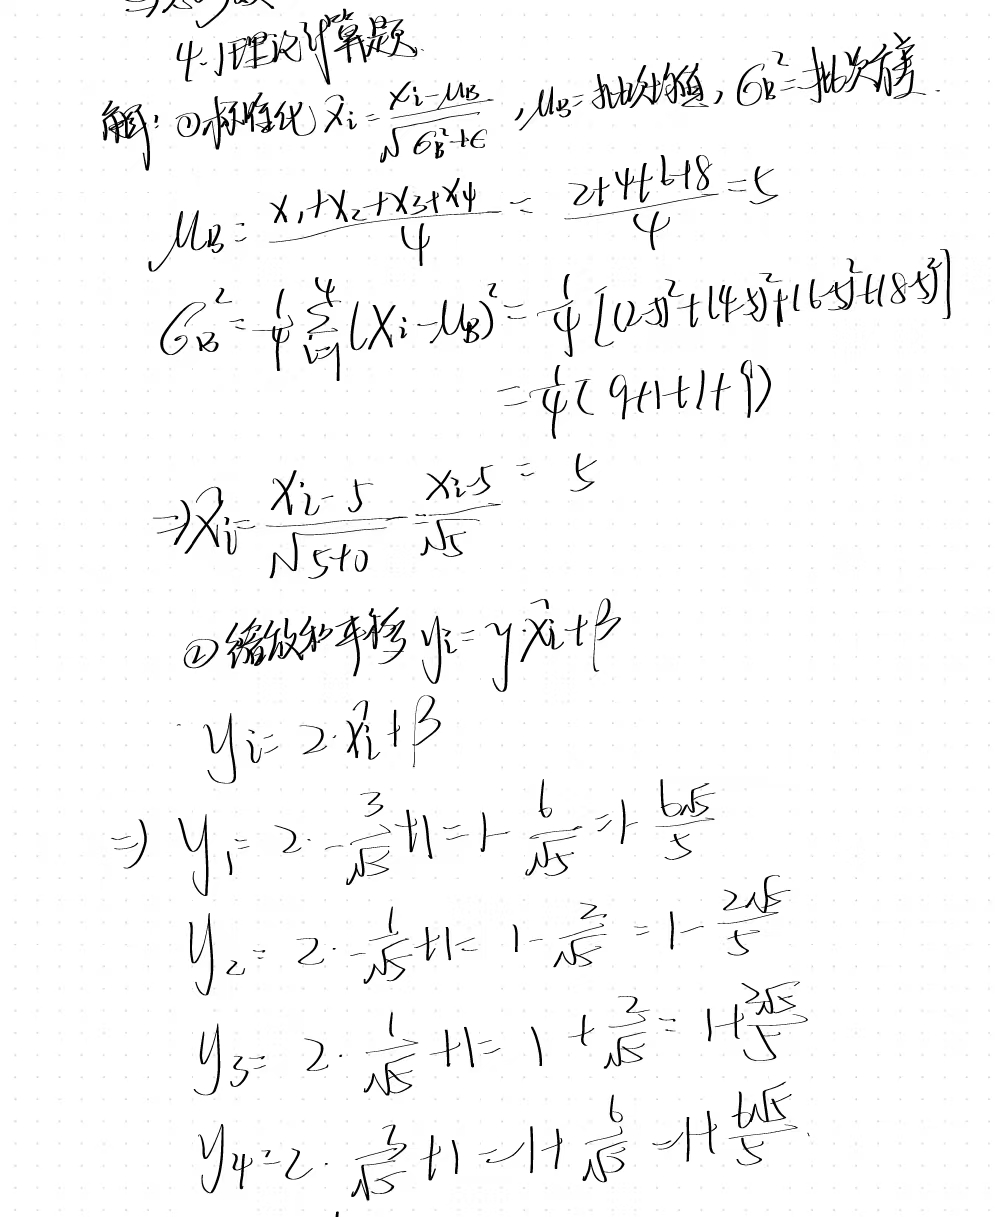

4.2 编程题
残差网络（ResNet）通过引入跨层连接（残差连接）解决了深层网络的梯度消失问题。请用 PyTorch 自定义一个残差块类 ‘Residual‘。
要求：该块包含两个具有相同输出通道数的 3 × 3 卷积层，每个卷积层后跟一个批量归一化层。如果 ‘use_1x1conv=True‘，则需要对输入应用一
个 1 × 1 的卷积层来调整输入的通道数和形状，以便它能和第二层卷积的输出进行按元素相加（f(x) + x）。

In [2]:
# 4.2 残差块实现
import torch
import torch.nn as nn

class Residual(nn.Module):
    """
    残差块：两个3x3卷积层 + 批量归一化 + 残差连接
    """
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        
        # 第一个卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # 第二个卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 如果需要调整输入形状（1x1卷积）
        if use_1x1conv or stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            self.bn_shortcut = nn.BatchNorm2d(out_channels)
        else:
            self.shortcut = None
    
    def forward(self, x):
        # 残差路径
        residual = x
        
        # 主路径
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # 快捷连接
        if self.shortcut is not None:
            residual = self.shortcut(x)
            residual = self.bn_shortcut(residual)
        
        # 相加 + ReLU
        out += residual
        out = self.relu(out)
        
        return out

# ========== 测试代码 ==========
print("="*60)
print("4.2 残差块实现")
print("="*60)

# 测试1: 输入输出通道相同，不需要1x1卷积
print("\n测试1: 输入输出通道相同 (in=64, out=64, use_1x1conv=False)")
block1 = Residual(in_channels=64, out_channels=64, use_1x1conv=False)
test_input1 = torch.randn(4, 64, 32, 32)
output1 = block1(test_input1)
print(f"输入形状: {test_input1.shape}")
print(f"输出形状: {output1.shape}")

# 测试2: 输入输出通道不同，需要1x1卷积
print("\n测试2: 输入输出通道不同 (in=32, out=64, use_1x1conv=True)")
block2 = Residual(in_channels=32, out_channels=64, use_1x1conv=True)
test_input2 = torch.randn(4, 32, 32, 32)
output2 = block2(test_input2)
print(f"输入形状: {test_input2.shape}")
print(f"输出形状: {output2.shape}")

# 测试3: 步幅为2，下采样
print("\n测试3: 步幅为2，下采样 (in=64, out=128, stride=2)")
block3 = Residual(in_channels=64, out_channels=128, use_1x1conv=True, stride=2)
test_input3 = torch.randn(4, 64, 32, 32)
output3 = block3(test_input3)
print(f"输入形状: {test_input3.shape}")
print(f"输出形状: {output3.shape}")

# 测试4: 不调整形状，通过参数自动判断
print("\n测试4: 自动判断是否需要1x1卷积 (in=64, out=128, stride=2)")
block4 = Residual(in_channels=64, out_channels=128, use_1x1conv=False, stride=2)
test_input4 = torch.randn(4, 64, 32, 32)
output4 = block4(test_input4)
print(f"输入形状: {test_input4.shape}")
print(f"输出形状: {output4.shape}")

# 打印网络结构
print(f"\n残差块结构示例:")
print(block1)

# 计算参数量
total_params = sum(p.numel() for p in block1.parameters())
print(f"\n残差块参数量 (in=64, out=64): {total_params:,}")

print("\n" + "="*60)
print("✅ 4.2 部分完成！")
print("="*60)

4.2 残差块实现

测试1: 输入输出通道相同 (in=64, out=64, use_1x1conv=False)
输入形状: torch.Size([4, 64, 32, 32])
输出形状: torch.Size([4, 64, 32, 32])

测试2: 输入输出通道不同 (in=32, out=64, use_1x1conv=True)
输入形状: torch.Size([4, 32, 32, 32])
输出形状: torch.Size([4, 64, 32, 32])

测试3: 步幅为2，下采样 (in=64, out=128, stride=2)
输入形状: torch.Size([4, 64, 32, 32])
输出形状: torch.Size([4, 128, 16, 16])

测试4: 自动判断是否需要1x1卷积 (in=64, out=128, stride=2)
输入形状: torch.Size([4, 64, 32, 32])
输出形状: torch.Size([4, 128, 16, 16])

残差块结构示例:
Residual(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)

残差块参数量 (in=64, out=64): 74,112

✅ 4.2 部分完成！


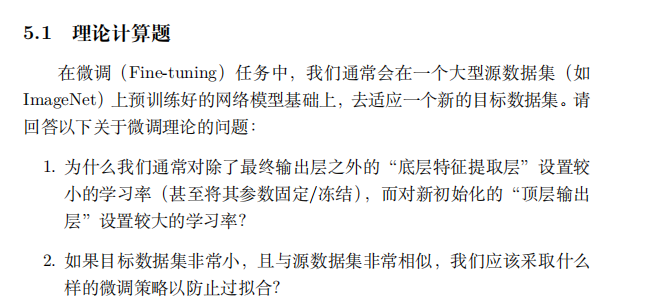

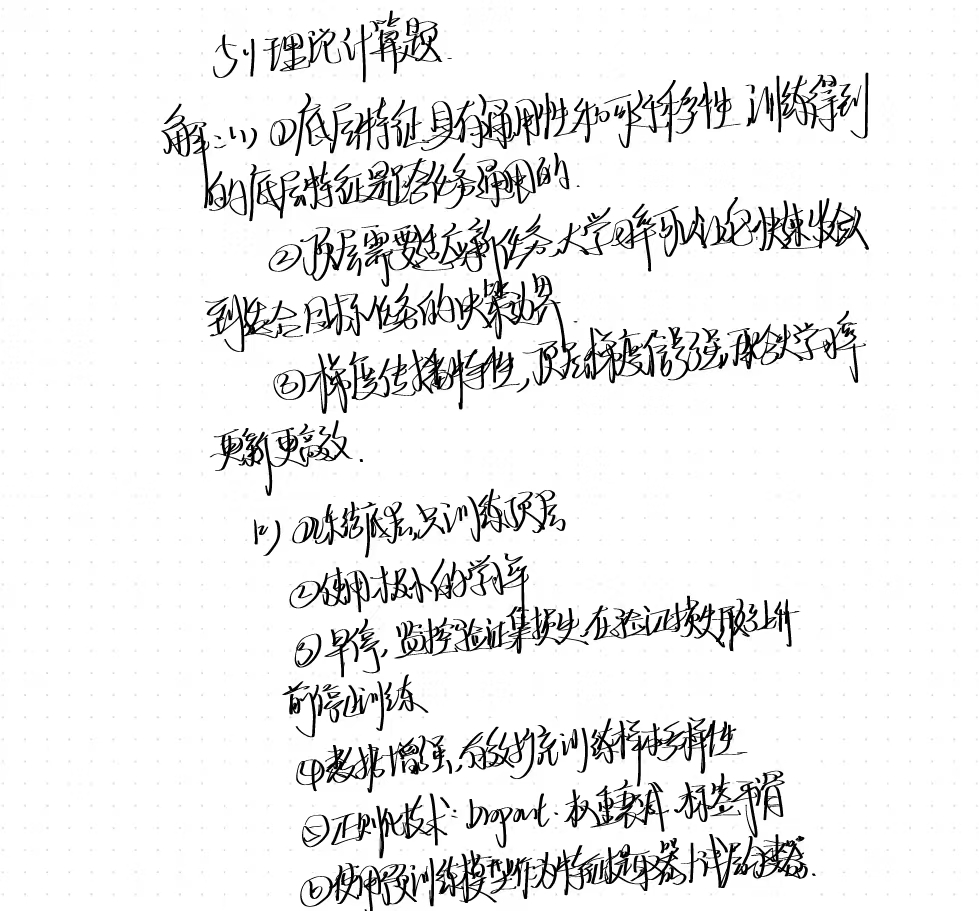

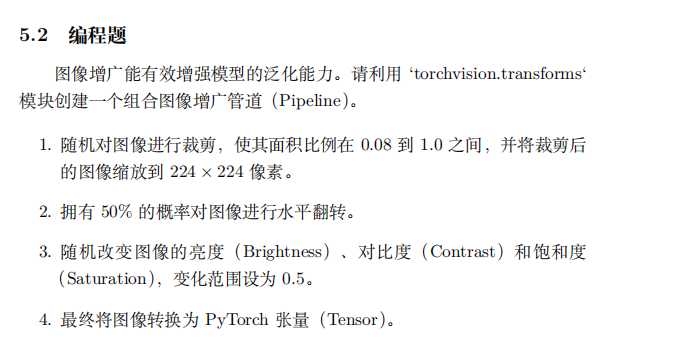

In [3]:
# 5.2 图像增广管道
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

def create_augmentation_pipeline():
    """
    创建图像增广管道：
    1. 随机裁剪到0.08-1.0面积比例，缩放至224x224
    2. 50%概率水平翻转
    3. 随机改变亮度、对比度、饱和度（范围0.5）
    4. 转换为张量
    """
    pipeline = transforms.Compose([
        # 1. 随机裁剪并缩放
        transforms.RandomResizedCrop(
            size=(224, 224),
            scale=(0.08, 1.0),   # 面积比例范围
            ratio=(0.75, 1.333)   # 宽高比范围
        ),
        # 2. 随机水平翻转（50%概率）
        transforms.RandomHorizontalFlip(p=0.5),
        # 3. 随机颜色抖动
        transforms.ColorJitter(
            brightness=0.5,
            contrast=0.5,
            saturation=0.5,
            hue=0.5
        ),
        # 4. 转换为张量
        transforms.ToTensor()
    ])
    
    return pipeline

# ========== 测试代码 ==========
print("="*60)
print("5.2 图像增广管道")
print("="*60)

# 创建增广管道
aug_pipeline = create_augmentation_pipeline()

print(f"\n增广管道结构:")
print(aug_pipeline)

# 创建模拟图像（用随机数组模拟）
# 创建一个300x300的彩色图像
dummy_image = Image.fromarray(np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8))

print(f"\n模拟图像信息:")
print(f"  类型: {type(dummy_image)}")
print(f"  尺寸: {dummy_image.size}")
print(f"  模式: {dummy_image.mode}")

# 应用增广，展示不同效果
print("\n应用增广5次（同一张图的不同效果）:")
for i in range(5):
    augmented = aug_pipeline(dummy_image)
    print(f"  第{i+1}次: 输出张量形状 = {augmented.shape}, "
          f"值范围 = [{augmented.min():.3f}, {augmented.max():.3f}]")

# 验证输出格式
sample = aug_pipeline(dummy_image)
print(f"\n输出张量信息:")
print(f"  形状: {sample.shape}")
print(f"  数据类型: {sample.dtype}")
print(f"  值范围: [{sample.min():.3f}, {sample.max():.3f}]")

# 验证通道顺序（应该是 C×H×W）
print(f"  通道顺序: {sample.shape[0]}通道 × {sample.shape[1]}高 × {sample.shape[2]}宽")

print("\n" + "="*60)
print("✅ 5.2 部分完成！")
print("="*60)

5.2 图像增广管道

增广管道结构:
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=(-0.5, 0.5))
    ToTensor()
)

模拟图像信息:
  类型: <class 'PIL.Image.Image'>
  尺寸: (300, 300)
  模式: RGB

应用增广5次（同一张图的不同效果）:
  第1次: 输出张量形状 = torch.Size([3, 224, 224]), 值范围 = [0.000, 1.000]
  第2次: 输出张量形状 = torch.Size([3, 224, 224]), 值范围 = [0.000, 1.000]
  第3次: 输出张量形状 = torch.Size([3, 224, 224]), 值范围 = [0.035, 0.788]
  第4次: 输出张量形状 = torch.Size([3, 224, 224]), 值范围 = [0.000, 0.961]
  第5次: 输出张量形状 = torch.Size([3, 224, 224]), 值范围 = [0.055, 0.922]

输出张量信息:
  形状: torch.Size([3, 224, 224])
  数据类型: torch.float32
  值范围: [0.075, 0.502]
  通道顺序: 3通道 × 224高 × 224宽

✅ 5.2 部分完成！


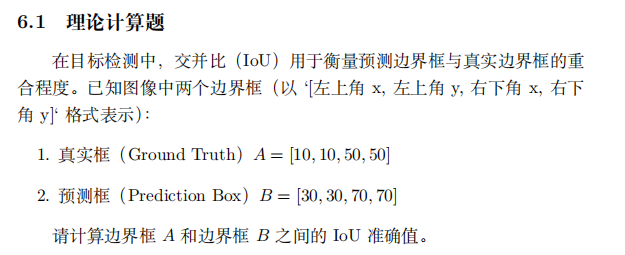

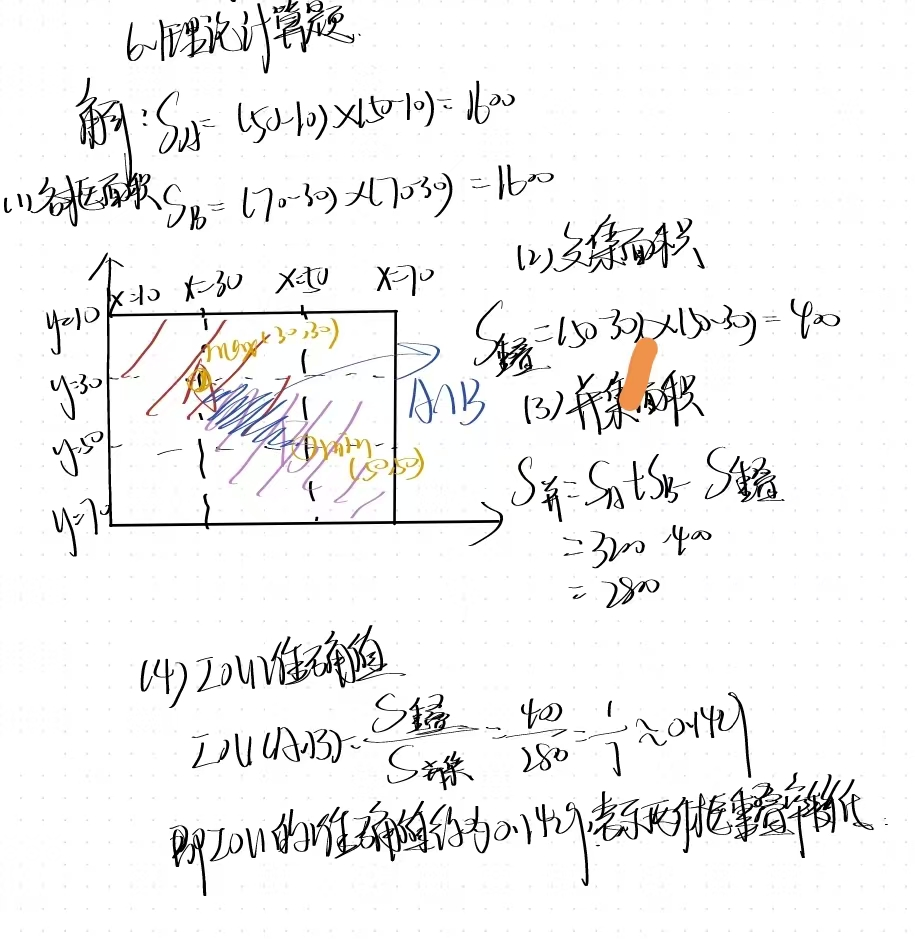

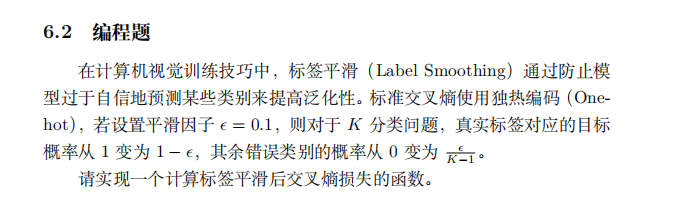

In [4]:
# 6.2 标签平滑交叉熵损失
import torch
import torch.nn as nn
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, labels, epsilon=0.1):
    """
    标签平滑交叉熵损失
    
    参数:
        logits: 模型输出，形状 (batch_size, num_classes)
        labels: 真实标签，形状 (batch_size,)
        epsilon: 平滑因子，默认0.1
    
    返回:
        loss: 平均损失
    """
    num_classes = logits.shape[1]
    batch_size = logits.shape[0]
    
    # 计算log_softmax（数值稳定）
    log_probs = F.log_softmax(logits, dim=1)
    
    # 创建平滑标签
    # 真实类别概率: 1 - epsilon，其他类别: epsilon / (K - 1)
    smooth_labels = torch.full_like(log_probs, epsilon / (num_classes - 1))
    smooth_labels.scatter_(1, labels.unsqueeze(1), 1.0 - epsilon)
    
    # 计算交叉熵损失
    loss = -torch.sum(smooth_labels * log_probs) / batch_size
    
    return loss


# 使用nn.Module封装
class LabelSmoothingCrossEntropy(nn.Module):
    """标签平滑交叉熵损失模块"""
    def __init__(self, epsilon=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon
    
    def forward(self, logits, labels):
        return label_smoothing_cross_entropy(logits, labels, self.epsilon)


# ========== 测试代码 ==========
print("="*60)
print("6.2 标签平滑交叉熵损失")
print("="*60)

# 创建测试数据
batch_size = 4
num_classes = 10
logits = torch.randn(batch_size, num_classes)
labels = torch.tensor([0, 2, 5, 7])

print(f"\n输入信息:")
print(f"  logits形状: {logits.shape}")
print(f"  labels: {labels}")

# 计算标准交叉熵（作为对比）
standard_loss = F.cross_entropy(logits, labels)
print(f"\n标准交叉熵损失: {standard_loss:.6f}")

# 计算标签平滑损失
smooth_loss = label_smoothing_cross_entropy(logits, labels, epsilon=0.1)
print(f"标签平滑损失 (ε=0.1): {smooth_loss:.6f}")

# 测试不同epsilon值
print("\n不同平滑因子的效果:")
for eps in [0.0, 0.05, 0.1, 0.2, 0.5]:
    loss = label_smoothing_cross_entropy(logits, labels, epsilon=eps)
    print(f"  ε={eps}: {loss:.6f}")

# 验证平滑标签的构造
print("\n验证平滑标签构造 (以第一个样本为例):")
num_classes = 5  # 用5类演示更清晰
sample_logits = torch.randn(1, num_classes)
sample_label = torch.tensor([2])

# 计算平滑标签
epsilon = 0.1
smooth_label = torch.full((1, num_classes), epsilon / (num_classes - 1))
smooth_label.scatter_(1, sample_label.unsqueeze(1), 1.0 - epsilon)

print(f"  类别数 K = {num_classes}")
print(f"  真实标签 = {sample_label.item()}")
print(f"  平滑标签 = {smooth_label[0].tolist()}")
print(f"  概率和 = {smooth_label.sum().item():.4f} (应为1)")

# 使用Module封装
print("\n使用Module封装:")
criterion = LabelSmoothingCrossEntropy(epsilon=0.1)
loss_module = criterion(logits, labels)
print(f"  损失值: {loss_module:.6f}")

print("\n" + "="*60)
print("✅ 6.2 部分完成！")
print("="*60)

6.2 标签平滑交叉熵损失

输入信息:
  logits形状: torch.Size([4, 10])
  labels: tensor([0, 2, 5, 7])

标准交叉熵损失: 2.491113
标签平滑损失 (ε=0.1): 2.503865

不同平滑因子的效果:
  ε=0.0: 2.491113
  ε=0.05: 2.497489
  ε=0.1: 2.503865
  ε=0.2: 2.516617
  ε=0.5: 2.554873

验证平滑标签构造 (以第一个样本为例):
  类别数 K = 5
  真实标签 = 2
  平滑标签 = [0.02500000037252903, 0.02500000037252903, 0.8999999761581421, 0.02500000037252903, 0.02500000037252903]
  概率和 = 1.0000 (应为1)

使用Module封装:
  损失值: 2.503865

✅ 6.2 部分完成！
